# Percobaan Praktikum 1 - TM 3
## Nama: Faiz Iqbal I'tishom
## NIM: 164231059
## Kelas: SD-A1

### Import Library

In [1]:
import cv2
import os
import pandas as pd
import numpy as np
from numpy import array
from numpy import argmax
import matplotlib.pyplot as plt
from scipy.io import wavfile
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## 1. Percobaan Praktikum Akusisi dan Representasi Data Image

In [2]:
img = cv2.imread("C:/Uner/Semester 5/Data Mining II/Coolyeah/Lenna_(test_image).png")

In [3]:
cv2.imshow("Citra Lenna", img)
cv2.waitKey(1)

-1

In [4]:
print("Ukuran Citra Warna", img.shape)
print("Matriks dari Citra Warna pada baris 0 dan kolom 0", img[0,0])

Ukuran Citra Warna (500, 500, 3)
Matriks dari Citra Warna pada baris 0 dan kolom 0 [124 137 226]


In [5]:
(blue, green, red) = cv2.split(img)

In [6]:
# buat matriks nol
zeros = np.zeros(img.shape[:2], dtype="uint8")

# hasil channel biru (RGB = [B,0,0])
blue_img = cv2.merge([blue, zeros, zeros])

# gabungkan citra asli + citra biru secara horizontal
combined = np.hstack([img, blue_img])

# tampilkan hasil
cv2.imshow("Semua Citra", combined)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Tugas Praktikum: Data Image

### A. Modifikasi kode bagian (a) agar dapat menampilkan citra ‘Lenna.png’ dalam grayscale.

In [7]:
img = cv2.imread("C:/Uner/Semester 5/Data Mining II/Coolyeah/Lenna_(test_image).png")

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2.imshow("Citra Lenna Grayscale", gray_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

### B. Modifikasi kode bagian (a) agar bisa melakukan crop pada citra ‘Lenna.png’ (terserah dibagian mana saja).

In [8]:
cropped = img[100:300, 150:350]

cv2.imshow("Citra Asli", img)
cv2.imshow("Citra Crop", cropped)

cv2.waitKey(0)
cv2.destroyAllWindows()

### C. Modifikasi kode bagian (b) agar dapat menampilkan ukuran citra grayscale dari ‘Lenna.png’ dan nilai matriks dari citra grayscale ‘Lenna.pg’ pada baris ke-0 dan kolom ke-0. Apakah hasilnya berbeda dengan bagian (b), jelaskan alasannya.

In [9]:
print("Ukuran Citra Grayscale:", gray_img.shape)

print("Matriks dari Citra Grayscale pada baris 0 kolom 0:", gray_img[0,0])

Ukuran Citra Grayscale: (500, 500)
Matriks dari Citra Grayscale pada baris 0 kolom 0: 162


### D. Modifikasi kode bagian (c) untuk menampilkan channel Green dan Red.

In [10]:
blue, green, red = cv2.split(img)

zeros = np.zeros(img.shape[:2], dtype="uint8")

blue_img  = cv2.merge([blue, zeros, zeros])
green_img = cv2.merge([zeros, green, zeros])
red_img   = cv2.merge([zeros, zeros, red])

top_row = np.hstack([img, blue_img])
bottom_row = np.hstack([green_img, red_img])
combined = np.vstack([top_row, bottom_row])

scale_percent = 50 
width = int(combined.shape[1] * scale_percent / 100)
height = int(combined.shape[0] * scale_percent / 100)
dim = (width, height)

resized = cv2.resize(combined, dim, interpolation=cv2.INTER_AREA)

cv2.imshow("Citra Lenna: ", resized)
cv2.waitKey(0)
cv2.destroyAllWindows()

### E. Simpanlah file ‘Lenna.png’ menjadi format JPEG dengan menggunakan method imwrite pada OpenCV, apakah terdapat perbedaan nilai array pada file citra asli dan file dengan format JPEG? Jelaskan alasannya.

In [11]:
cv2.imwrite("Lenna.jpg", img)

True

In [12]:
img_jpeg = cv2.imread("C:/Uner/Semester 5/Data Mining II/Coolyeah/Lenna.jpg")

print("Perbedaan nilai array:", (img != img_jpeg).sum())

Perbedaan nilai array: 647629


## 2. Percobaan Praktikum Akuisisi dan Representasi Data Audio

### a. Mencoba membuat sinyal audio berupa gelombang.

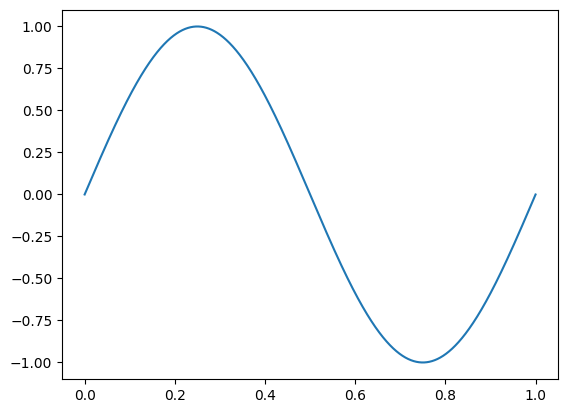

In [13]:
sr = 44100
freq = 1
length = 1
t = np.arange(0, length, 1.0/sr)
signal = np.sin(np.pi*2*freq*t)

plt.plot(t, signal)
plt.show()

In [14]:
wavfile.write("file.wav", sr, signal)

### b. Supaya terdengar manusia, kita harus mengganti frekuensinya. Misalkan, kita mengubah frekuensinya menjadi 200.

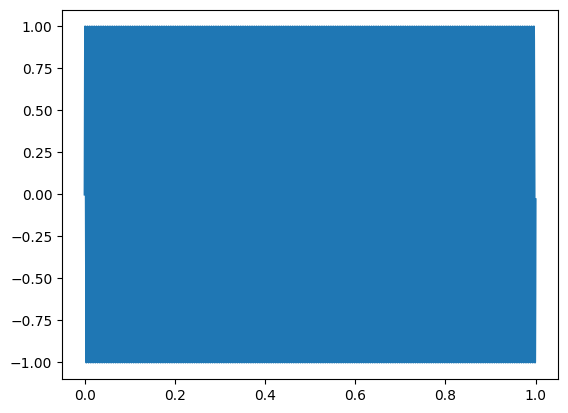

In [15]:
freq1 = 200
signal1 = np.sin(np.pi*2*freq1*t)
t1 = np.arange(0, length, 1.0/sr)

plt.plot(t1, signal1)
plt.show()

In [16]:
wavfile.write("file1.wav", sr, signal1)

## Tugas Praktikum: Data Audio

### A. Modifikasi kode bagian (a) agar membuat gelombang suara dengan frekuensi 400. Berapa panjang gelombangnya sekarang? Apakah file suara yang dihasilkan frekuensi 400 berbeda dengan file suara yang dihasilkan kode bagian (b)? jelaskan alasannya.

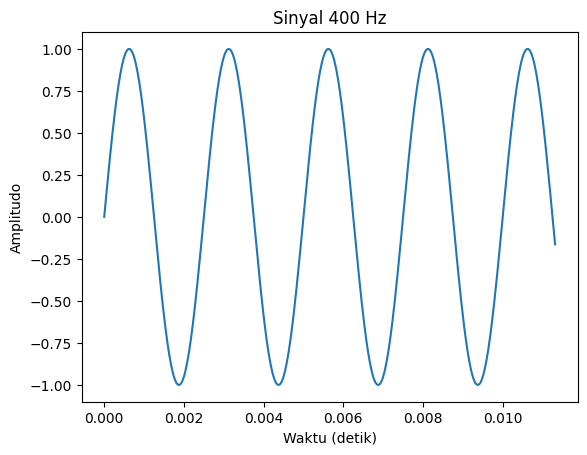

In [17]:
sr = 44100   
freq = 400      
length = 1      

t = np.arange(0, length, 1.0/sr)     
signal = np.sin(2 * np.pi * freq * t)

plt.plot(t[:500], signal[:500])   
plt.title(f"Sinyal {freq} Hz")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.show()

In [18]:
wavfile.write("file2.wav", sr, np.int16(signal * 32767))

### B. Modifikasi kode bagian (b) dengan mengganti nilai amplitudo menjadi 50. Pada output gelombang, berapakah panjang dan tinggi gelombang sekarang? Apakah terdapat perbedaan bunyi dengan hasil suara dari kode bagian (b)? jelaskan alasannya.

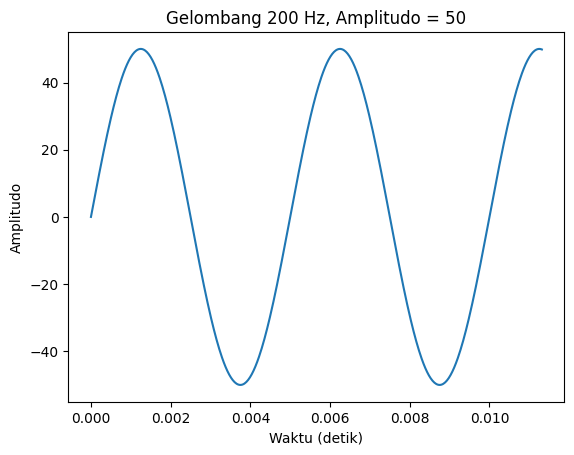

In [19]:
sr = 44100
freq1 = 200
length = 1

t1 = np.arange(0, length, 1.0/sr)

signal1 = 50 * np.sin(2 * np.pi * freq1 * t1)

plt.plot(t1[:500], signal1[:500])  
plt.title("Gelombang 200 Hz, Amplitudo = 50")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.show()

In [20]:
wavfile.write("file3.wav", sr, np.int16(signal1))

## 3. Percobaan Praktikum Akuisisi dan Representasi Data Teks

### a. ASCII

In [21]:
char = 'A'
print(ord(char))

65


In [22]:
ascii = 65
print(chr(ascii))

A


### b. One-Hot Encoding

In [23]:
docs = "I ate an apple"

split_docs = docs.split(" ")
data = [doc.split(" ") for doc in split_docs]
values = array(data).ravel()

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(values)
print(integer_encoded)

[0 3 1 2]


In [24]:
onehot_encoder = OneHotEncoder(sparse_output=False)
integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
onehot_encoded = onehot_encoder.fit_transform(integer_encoded)
print(onehot_encoded)

[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]


### c. Count Vectorizer

In [25]:
text = ["everybody love nlp", "nlp is so cool", "nlp is all about helping machines process language", "this tutorial is on basic nlp technique"]
vectorizer = CountVectorizer()

vectorizer.fit(text)
print(vectorizer.vocabulary_)

vector = vectorizer.transform(text)

print(vector.shape)
print(vector.toarray())

{'everybody': 4, 'love': 8, 'nlp': 10, 'is': 6, 'so': 13, 'cool': 3, 'all': 1, 'about': 0, 'helping': 5, 'machines': 9, 'process': 12, 'language': 7, 'this': 15, 'tutorial': 16, 'on': 11, 'basic': 2, 'technique': 14}
(4, 17)
[[0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0]
 [1 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 0]
 [0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1]]


### d. TF-IDF 

In [26]:
text1 = ["everybody love nlp", "nlp is so cool", "nlp is all about helping machines process language", "this tutorial is on basic nlp technique"]
tf = TfidfVectorizer()
txt_fitted = tf.fit(text1)
txt_transformed = txt_fitted.transform(text1)

idf = tf.idf_
print(dict(zip(txt_fitted.get_feature_names_out(), idf)))

{'about': np.float64(1.916290731874155), 'all': np.float64(1.916290731874155), 'basic': np.float64(1.916290731874155), 'cool': np.float64(1.916290731874155), 'everybody': np.float64(1.916290731874155), 'helping': np.float64(1.916290731874155), 'is': np.float64(1.2231435513142097), 'language': np.float64(1.916290731874155), 'love': np.float64(1.916290731874155), 'machines': np.float64(1.916290731874155), 'nlp': np.float64(1.0), 'on': np.float64(1.916290731874155), 'process': np.float64(1.916290731874155), 'so': np.float64(1.916290731874155), 'technique': np.float64(1.916290731874155), 'this': np.float64(1.916290731874155), 'tutorial': np.float64(1.916290731874155)}


## Tugas Praktikum: Data Text

### A. Modifikasi kode bagian (a) agar bisa menampilkan ASCII code untuk kata ‘datA mining’

In [27]:
chara = "datA mining"

for char in chara:
    print(f"Karakter: {char}  ->  ASCII: {ord(char)}")


Karakter: d  ->  ASCII: 100
Karakter: a  ->  ASCII: 97
Karakter: t  ->  ASCII: 116
Karakter: A  ->  ASCII: 65
Karakter:    ->  ASCII: 32
Karakter: m  ->  ASCII: 109
Karakter: i  ->  ASCII: 105
Karakter: n  ->  ASCII: 110
Karakter: i  ->  ASCII: 105
Karakter: n  ->  ASCII: 110
Karakter: g  ->  ASCII: 103


### B. Tambahkan kode bagian (b) agar bisa menampilkan kembali kata pertama yang di lakukan one-hot encoding

In [28]:
docs = "I ate an apple"

split_docs = docs.split(" ")
data = [doc.split(" ") for doc in split_docs]
values = array(data).ravel()

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(values)
print("Label Encoding:", integer_encoded)

onehot_encoder = OneHotEncoder(sparse_output=False)
integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
onehot_encoded = onehot_encoder.fit_transform(integer_encoded)
print("One-Hot Encoding:\n", onehot_encoded)

first_word_index = integer_encoded[0][0]     
first_word = label_encoder.inverse_transform([first_word_index])[0]

print("Kata pertama setelah decoding:", first_word)

Label Encoding: [0 3 1 2]
One-Hot Encoding:
 [[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
Kata pertama setelah decoding: I


### C. Download file tugas_text_representation.csv dari hebat e learning, kemudian lakukan CountVectorizer dan TF-IDF pada korpus tersebut. Jelaskan hasil yang didapatkan.

In [29]:
file_path = r"C:/Uner/Semester 5/Data Mining II/Coolyeah/1998.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

corpus = [text]

count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(corpus)

print("=== CountVectorizer ===")
print("Fitur (kata-kata):")
print(count_vectorizer.get_feature_names_out())
print("\nMatriks Count (jumlah kemunculan kata):")
print(count_matrix.toarray())

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print("\n=== TF-IDF ===")
print("Fitur (kata-kata):")
print(tfidf_vectorizer.get_feature_names_out())
print("\nMatriks TF-IDF (bobot kata):")
print(tfidf_matrix.toarray())

=== CountVectorizer ===
Fitur (kata-kata):
['00' '000' '01' ... 'zhou' 'zhu' '黑色的五月']

Matriks Count (jumlah kemunculan kata):
[[1 6 1 ... 1 1 1]]

=== TF-IDF ===
Fitur (kata-kata):
['00' '000' '01' ... 'zhou' 'zhu' '黑色的五月']

Matriks TF-IDF (bobot kata):
[[0.00268128 0.0160877  0.00268128 ... 0.00268128 0.00268128 0.00268128]]


In [30]:
df_count = pd.DataFrame(count_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())
print(df_count)

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(df_tfidf)

   00  000  01  02  05  09  10  100  101  109  ...  yuanyan  yudhoyono  \
0   1    6   1   1   1   2   4    2    1    1  ...        1          1   

   yunling  yuzaini  zemin  zha  zhang  zhou  zhu  黑色的五月  
0        1        1      4    1      2     1    1      1  

[1 rows x 1424 columns]
         00       000        01        02        05        09        10  \
0  0.002681  0.016088  0.002681  0.002681  0.002681  0.005363  0.010725   

        100       101       109  ...   yuanyan  yudhoyono   yunling   yuzaini  \
0  0.005363  0.002681  0.002681  ...  0.002681   0.002681  0.002681  0.002681   

      zemin       zha     zhang      zhou       zhu     黑色的五月  
0  0.010725  0.002681  0.005363  0.002681  0.002681  0.002681  

[1 rows x 1424 columns]


### D. Modifikasi kode bagian (d) agar bisa menampilkan grafik dari tiap kata. contohnya seperti gambar di bawah.

{'about': np.float64(1.916290731874155), 'all': np.float64(1.916290731874155), 'basic': np.float64(1.916290731874155), 'cool': np.float64(1.916290731874155), 'everybody': np.float64(1.916290731874155), 'helping': np.float64(1.916290731874155), 'is': np.float64(1.2231435513142097), 'language': np.float64(1.916290731874155), 'love': np.float64(1.916290731874155), 'machines': np.float64(1.916290731874155), 'nlp': np.float64(1.0), 'on': np.float64(1.916290731874155), 'process': np.float64(1.916290731874155), 'so': np.float64(1.916290731874155), 'technique': np.float64(1.916290731874155), 'this': np.float64(1.916290731874155), 'tutorial': np.float64(1.916290731874155)}


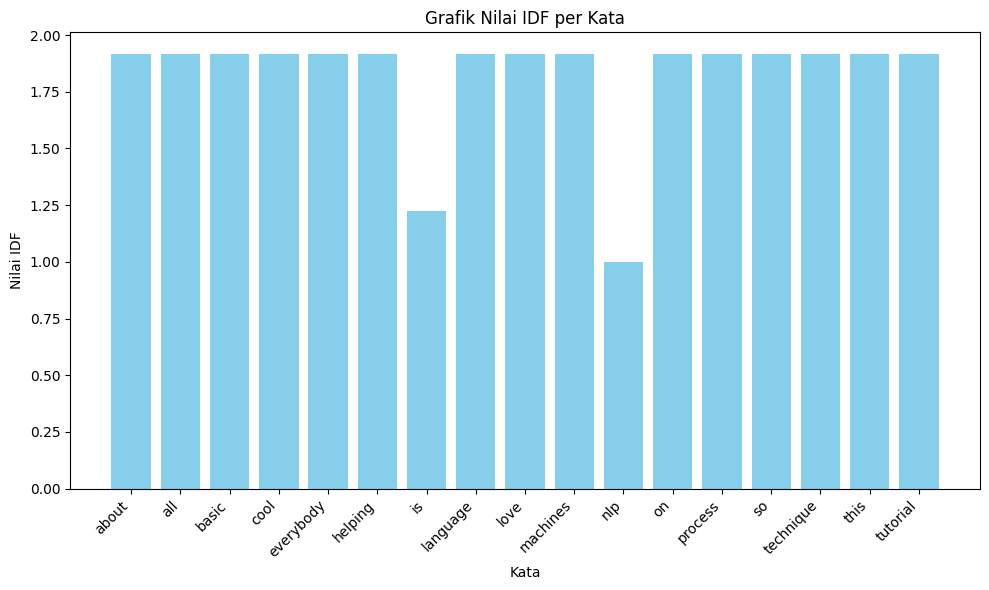

In [31]:
text1 = [
    "everybody love nlp",
    "nlp is so cool",
    "nlp is all about helping machines process language",
    "this tutorial is on basic nlp technique"
]

tf = TfidfVectorizer()
txt_fitted = tf.fit(text1)

idf = tf.idf_
words = tf.get_feature_names_out()

print(dict(zip(words, idf)))

plt.figure(figsize=(10, 6))
plt.bar(words, idf, color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Kata")
plt.ylabel("Nilai IDF")
plt.title("Grafik Nilai IDF per Kata")
plt.tight_layout()
plt.show()